Week 18 · Day 6 — Exploration & Stability Tricks
Why this matters

Even a strong RL algorithm fails if it can’t balance exploration (trying new actions) and stability (learning consistent behavior).
Today you’ll experiment with entropy, reward normalization, and gradient clipping to keep learning reliable.

Theory Essentials (≤ 6 bullets)

Exploration–Exploitation trade-off → agents must both try and exploit.

Entropy bonus → keeps policies stochastic early on.

Reward normalization/scaling → stabilizes gradient magnitudes.

Gradient clipping → prevents exploding updates.

Too little entropy = premature convergence; too much = wandering agent.

Goal: achieve smooth, consistent reward growth.

Ep   50 | Avg Reward (50): 18.0 | Entropy ≈ 0.665
Ep  100 | Avg Reward (50): 23.6 | Entropy ≈ 0.688
Ep  150 | Avg Reward (50): 30.7 | Entropy ≈ 0.674
Ep  200 | Avg Reward (50): 43.1 | Entropy ≈ 0.656
Ep  250 | Avg Reward (50): 57.5 | Entropy ≈ 0.636
Ep  300 | Avg Reward (50): 74.1 | Entropy ≈ 0.625
Ep  350 | Avg Reward (50): 119.6 | Entropy ≈ 0.606
Ep  400 | Avg Reward (50): 158.6 | Entropy ≈ 0.596


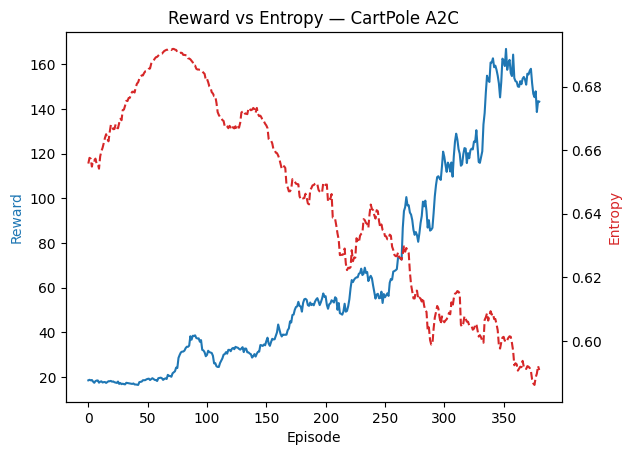

In [1]:
# Setup
import numpy as np, matplotlib.pyplot as plt
import gymnasium as gym
import torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
from torch.nn.utils import clip_grad_norm_
np.random.seed(42); torch.manual_seed(42)

# Environment
env = gym.make("CartPole-v1")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Actor–Critic model
class ActorCritic(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())
        self.policy = nn.Sequential(nn.Linear(hidden, n_actions), nn.Softmax(dim=-1))
        self.value = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.shared(x)
        return self.policy(x), self.value(x)

model = ActorCritic()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
gamma, beta, critic_coef = 0.99, 1e-3, 0.5
episodes = 400

def compute_returns(rewards, gamma=0.99):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    ret = torch.tensor(out, dtype=torch.float32)
    if ret.std() > 0:  # normalize
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

rewards_hist, entropy_hist = [], []

for ep in range(episodes):
    logp_list, val_list, rew_list, ent_list = [], [], [], []
    s, _ = env.reset()
    done = False; total = 0
    while not done:
        s_t = torch.tensor(s, dtype=torch.float32)
        probs, v = model(s_t)
        m = Categorical(probs)
        a = m.sample()
        s, r, term, trunc, _ = env.step(a.item())
        done = term or trunc
        logp_list.append(m.log_prob(a))
        val_list.append(v)
        rew_list.append(r)
        ent_list.append(m.entropy())
        total += r
    returns = compute_returns(rew_list, gamma)
    values = torch.cat(val_list).squeeze()
    adv = returns - values.detach()

    actor_loss = -(torch.stack(logp_list) * adv).mean()
    critic_loss = (returns - values).pow(2).mean()
    entropy_loss = -torch.stack(ent_list).mean()
    loss = actor_loss + critic_coef * critic_loss + beta * entropy_loss

    optimizer.zero_grad()
    loss.backward()
    clip_grad_norm_(model.parameters(), 1.0)  # stability
    optimizer.step()

    rewards_hist.append(total)
    entropy_hist.append(torch.stack(ent_list).mean().item())

    if (ep+1) % 50 == 0:
        print(f"Ep {ep+1:4d} | Avg Reward (50): {np.mean(rewards_hist[-50:]):.1f} | Entropy ≈ {np.mean(entropy_hist[-50:]):.3f}")

# Plot reward vs entropy
fig, ax1 = plt.subplots()
ax1.plot(np.convolve(rewards_hist, np.ones(20)/20, 'valid'), color='tab:blue')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(np.convolve(entropy_hist, np.ones(20)/20, 'valid'), color='tab:red', linestyle='--')
ax2.set_ylabel('Entropy', color='tab:red')
plt.title("Reward vs Entropy — CartPole A2C")
plt.show()


1) Core (10–15 min)

Task: Try beta = 0, 1e-3, 1e-2. Which gives faster yet stable convergence?

Ep   50 | Avg Reward (50): 19.3 | Entropy ≈ 0.663
Ep  100 | Avg Reward (50): 29.3 | Entropy ≈ 0.680
Ep  150 | Avg Reward (50): 44.0 | Entropy ≈ 0.648
Ep  200 | Avg Reward (50): 53.0 | Entropy ≈ 0.629
Ep  250 | Avg Reward (50): 71.3 | Entropy ≈ 0.616
Ep  300 | Avg Reward (50): 89.9 | Entropy ≈ 0.613
Ep  350 | Avg Reward (50): 135.2 | Entropy ≈ 0.609
Ep  400 | Avg Reward (50): 146.4 | Entropy ≈ 0.599


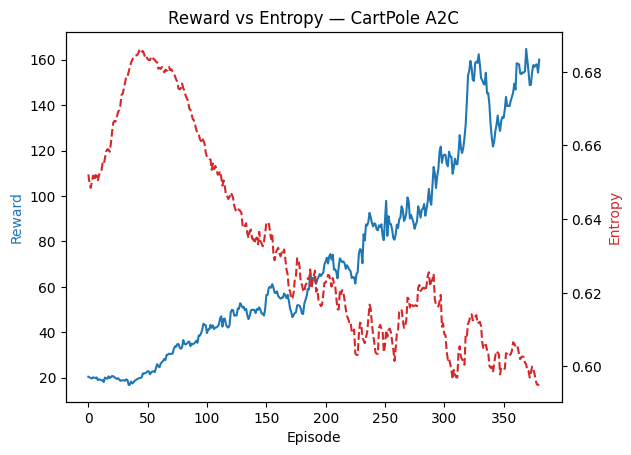

Ep   50 | Avg Reward (50): 24.1 | Entropy ≈ 0.688
Ep  100 | Avg Reward (50): 35.7 | Entropy ≈ 0.675
Ep  150 | Avg Reward (50): 40.3 | Entropy ≈ 0.643
Ep  200 | Avg Reward (50): 48.0 | Entropy ≈ 0.635
Ep  250 | Avg Reward (50): 63.3 | Entropy ≈ 0.623
Ep  300 | Avg Reward (50): 122.1 | Entropy ≈ 0.611
Ep  350 | Avg Reward (50): 138.4 | Entropy ≈ 0.597
Ep  400 | Avg Reward (50): 150.2 | Entropy ≈ 0.597


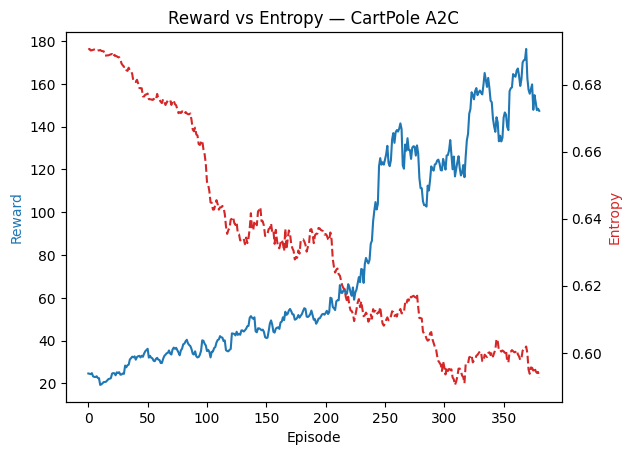

Ep   50 | Avg Reward (50): 28.2 | Entropy ≈ 0.679
Ep  100 | Avg Reward (50): 33.8 | Entropy ≈ 0.658
Ep  150 | Avg Reward (50): 40.4 | Entropy ≈ 0.636
Ep  200 | Avg Reward (50): 58.1 | Entropy ≈ 0.623
Ep  250 | Avg Reward (50): 74.2 | Entropy ≈ 0.622
Ep  300 | Avg Reward (50): 110.1 | Entropy ≈ 0.607
Ep  350 | Avg Reward (50): 146.7 | Entropy ≈ 0.602
Ep  400 | Avg Reward (50): 158.6 | Entropy ≈ 0.591


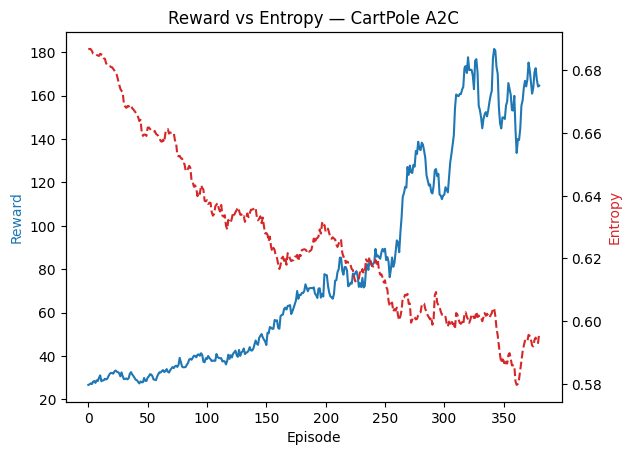

In [3]:
for beta in [0, 1e-3, 1e-2]:
    
    model = ActorCritic()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    rewards_hist, entropy_hist = [], []

    for ep in range(episodes):
        logp_list, val_list, rew_list, ent_list = [], [], [], []
        s, _ = env.reset()
        done = False; total = 0
        while not done:
            s_t = torch.tensor(s, dtype=torch.float32)
            probs, v = model(s_t)
            m = Categorical(probs)
            a = m.sample()
            s, r, term, trunc, _ = env.step(a.item())
            done = term or trunc
            logp_list.append(m.log_prob(a))
            val_list.append(v)
            rew_list.append(r)
            ent_list.append(m.entropy())
            total += r
        returns = compute_returns(rew_list, gamma)
        values = torch.cat(val_list).squeeze()
        adv = returns - values.detach()

        actor_loss = -(torch.stack(logp_list) * adv).mean()
        critic_loss = (returns - values).pow(2).mean()
        entropy_loss = -torch.stack(ent_list).mean()
        loss = actor_loss + critic_coef * critic_loss + beta * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)  # stability
        optimizer.step()

        rewards_hist.append(total)
        entropy_hist.append(torch.stack(ent_list).mean().item())

        if (ep+1) % 50 == 0:
            print(f"Ep {ep+1:4d} | Avg Reward (50): {np.mean(rewards_hist[-50:]):.1f} | Entropy ≈ {np.mean(entropy_hist[-50:]):.3f}")

    # Plot reward vs entropy
    fig, ax1 = plt.subplots()
    ax1.plot(np.convolve(rewards_hist, np.ones(20)/20, 'valid'), color='tab:blue')
    ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward', color='tab:blue')
    ax2 = ax1.twinx()
    ax2.plot(np.convolve(entropy_hist, np.ones(20)/20, 'valid'), color='tab:red', linestyle='--')
    ax2.set_ylabel('Entropy', color='tab:red')
    plt.title("Reward vs Entropy — CartPole A2C")
    plt.show()


2) Practice (10–15 min)

Task: Multiply rewards by 0.1 or 5 (reward scaling).

Ep   50 | Avg Reward (50): 20.0 | Entropy ≈ 0.674
Ep  100 | Avg Reward (50): 26.9 | Entropy ≈ 0.677
Ep  150 | Avg Reward (50): 32.5 | Entropy ≈ 0.665
Ep  200 | Avg Reward (50): 42.8 | Entropy ≈ 0.637
Ep  250 | Avg Reward (50): 65.8 | Entropy ≈ 0.614
Ep  300 | Avg Reward (50): 86.4 | Entropy ≈ 0.599
Ep  350 | Avg Reward (50): 112.6 | Entropy ≈ 0.598
Ep  400 | Avg Reward (50): 147.1 | Entropy ≈ 0.594


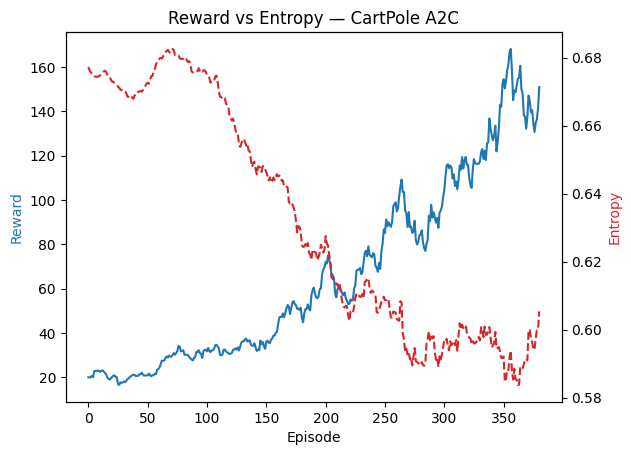

In [4]:
model = ActorCritic()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

rewards_hist, entropy_hist = [], []

for ep in range(episodes):
    logp_list, val_list, rew_list, ent_list = [], [], [], []
    s, _ = env.reset()
    done = False; total = 0
    while not done:
        s_t = torch.tensor(s, dtype=torch.float32)
        probs, v = model(s_t)
        m = Categorical(probs)
        a = m.sample()
        s, r, term, trunc, _ = env.step(a.item())
        done = term or trunc
        logp_list.append(m.log_prob(a))
        val_list.append(v)
        rew_list.append(r * 5)
        ent_list.append(m.entropy())
        total += r
    returns = compute_returns(rew_list, gamma)
    values = torch.cat(val_list).squeeze()
    adv = returns - values.detach()

    actor_loss = -(torch.stack(logp_list) * adv).mean()
    critic_loss = (returns - values).pow(2).mean()
    entropy_loss = -torch.stack(ent_list).mean()
    loss = actor_loss + critic_coef * critic_loss + beta * entropy_loss

    optimizer.zero_grad()
    loss.backward()
    clip_grad_norm_(model.parameters(), 1.0)  # stability
    optimizer.step()

    rewards_hist.append(total)
    entropy_hist.append(torch.stack(ent_list).mean().item())

    if (ep+1) % 50 == 0:
        print(f"Ep {ep+1:4d} | Avg Reward (50): {np.mean(rewards_hist[-50:]):.1f} | Entropy ≈ {np.mean(entropy_hist[-50:]):.3f}")

# Plot reward vs entropy
fig, ax1 = plt.subplots()
ax1.plot(np.convolve(rewards_hist, np.ones(20)/20, 'valid'), color='tab:blue')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Reward', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(np.convolve(entropy_hist, np.ones(20)/20, 'valid'), color='tab:red', linestyle='--')
ax2.set_ylabel('Entropy', color='tab:red')
plt.title("Reward vs Entropy — CartPole A2C")
plt.show()


3) Stretch (optional, 10–15 min)

Task: Plot entropy vs reward to visualize exploration decay.

When the red entropy curve drops sharply, the agent has reduced exploration — it’s becoming more confident and exploiting the best actions.

Mini-Challenge (≤ 40 min) — “Entropy Tuner”

Goal: find the β value that gives fast convergence without early collapse.

Acceptance Criteria

Train 3 agents (β ∈ {0, 1e-3, 1e-2}) on CartPole-v1.

Plot reward and entropy curves.

Report which β achieved the best balance (high reward + gradual entropy decay).

Hint: keep the same seed and plot on one chart for fairness.

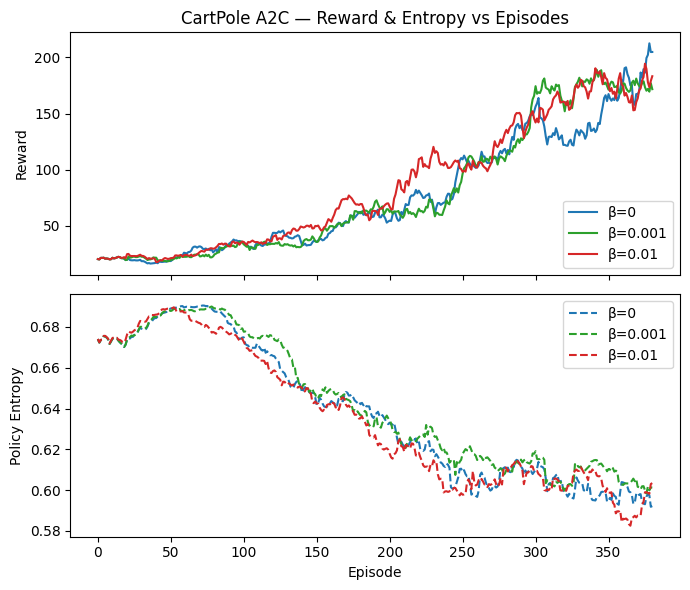

=== Summary (higher last-50 reward is better; later entropy drop = steadier exploration) ===
β=0 | last-50 reward: 181.16 | first entropy < 0.30 @ ep: None
β=0.001 | last-50 reward: 170.46 | first entropy < 0.30 @ ep: None
β=0.01 | last-50 reward: 175.08 | first entropy < 0.30 @ ep: None

👉 Recommendation: β=0 achieved the best balance (by this heuristic). Visually confirm on the plots: it should reach high reward while entropy decays gradually.


In [6]:
# Mini-Challenge — "Entropy Tuner": compare beta ∈ {0, 1e-3, 1e-2} fairly
import numpy as np, matplotlib.pyplot as plt, random, torch, torch.nn as nn, torch.optim as optim
from torch.distributions import Categorical
from torch.nn.utils import clip_grad_norm_
import gymnasium as gym

def set_seed(seed=42):
    np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)

def compute_returns(rewards, gamma=0.99):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    ret = torch.tensor(out, dtype=torch.float32)
    if ret.std() > 0:
        ret = (ret - ret.mean()) / (ret.std() + 1e-8)
    return ret

def train_agent(beta=1e-3, episodes=400, seed=42, lr=1e-3, gamma=0.99, critic_coef=0.5, hidden=128):
    set_seed(seed)
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    class ActorCritic(nn.Module):
        def __init__(self, hidden=128):
            super().__init__()
            self.shared = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())
            self.policy = nn.Sequential(nn.Linear(hidden, n_actions), nn.Softmax(dim=-1))
            self.value = nn.Linear(hidden, 1)
        def forward(self, x):
            x = self.shared(x)
            return self.policy(x), self.value(x)

    model = ActorCritic(hidden)
    opt = optim.Adam(model.parameters(), lr=lr)

    rewards_hist, entropy_hist = [], []

    for ep in range(episodes):
        s, _ = env.reset(seed=seed)
        done, total = False, 0.0
        logp_list, val_list, rew_list, ent_list = [], [], [], []

        while not done:
            s_t = torch.tensor(s, dtype=torch.float32)
            probs, v = model(s_t)
            m = Categorical(probs)
            a = m.sample()
            s, r, term, trunc, _ = env.step(a.item())
            done = term or trunc

            logp_list.append(m.log_prob(a))
            val_list.append(v)
            rew_list.append(r)
            ent_list.append(m.entropy())
            total += r

        returns = compute_returns(rew_list, gamma=gamma)
        values = torch.cat(val_list).squeeze()
        adv = returns - values.detach()

        actor_loss = -(torch.stack(logp_list) * adv).mean()
        critic_loss = (returns - values).pow(2).mean()
        entropy_loss = -torch.stack(ent_list).mean()
        loss = actor_loss + critic_coef * critic_loss + beta * entropy_loss

        opt.zero_grad(); loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        rewards_hist.append(total)
        entropy_hist.append(torch.stack(ent_list).mean().item())

    env.close()
    return np.array(rewards_hist), np.array(entropy_hist)

# --- Run the experiment ---
EPISODES = 400
BETAS = [0.0, 1e-3, 1e-2]
SEED = 123  # same seed for fairness
histories = {}  # beta -> (rewards, entropy)

for b in BETAS:
    rewards, entropy = train_agent(beta=b, episodes=EPISODES, seed=SEED)
    histories[b] = (rewards, entropy)

# --- Plot rewards & entropy (one chart per metric; all betas together) ---
def smooth(x, w=20):
    if len(x) < w: return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

colors = {0.0: 'tab:blue', 1e-3: 'tab:green', 1e-2: 'tab:red'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7,6), sharex=True)

for b, (r_hist, e_hist) in histories.items():
    r_sm, e_sm = smooth(r_hist), smooth(e_hist)
    xs_r = np.arange(len(r_sm))
    ax1.plot(xs_r, r_sm, label=f'β={b:g}', color=colors[b])
    ax2.plot(xs_r, e_sm, label=f'β={b:g}', color=colors[b], linestyle='--')

ax1.set_ylabel('Reward'); ax1.set_title('CartPole A2C — Reward & Entropy vs Episodes')
ax1.legend(loc='lower right')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Policy Entropy')
ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

# --- Simple report & recommendation ---
def stats_for(beta, last_k=50, entropy_thresh=0.30):
    r, e = histories[beta]
    last_mean = r[-last_k:].mean()
    # first episode where entropy falls below threshold (if any)
    below = np.where(e < entropy_thresh)[0]
    drop_ep = int(below[0]) if len(below) else None
    return last_mean, drop_ep

print("=== Summary (higher last-50 reward is better; later entropy drop = steadier exploration) ===")
scores = []
for b in BETAS:
    last50, drop_ep = stats_for(b)
    print(f"β={b:g} | last-50 reward: {last50:6.2f} | first entropy < 0.30 @ ep: {drop_ep}")
    # heuristic score: reward + small bonus for later entropy drop
    bonus = (drop_ep or EPISODES) / EPISODES
    scores.append((last50 + 10*bonus, b))  # weight bonus lightly

best_beta = max(scores)[1]
print(f"\n👉 Recommendation: β={best_beta:g} achieved the best balance (by this heuristic). "
      f"Visually confirm on the plots: it should reach high reward while entropy decays gradually.")


Notes / Key Takeaways

Entropy bonus keeps the policy exploring early on.

Reward normalization reduces gradient variance.

Reward scaling affects learning rate indirectly.

Gradient clipping prevents explosions from rare large updates.

Balancing these tricks = stable, efficient learning.

Most modern RL algorithms (PPO, A3C, SAC) include all of them.

Reflection

Why does adding entropy make training smoother?

How could poor reward scaling hide a good policy?

1. Why does adding entropy make training smoother?
Entropy encourages the agent to keep exploring instead of prematurely locking onto one action that looks good early on. This exploration helps avoid getting stuck in local optima and reduces variance between episodes. As a result, learning becomes more stable and gradual, leading to smoother reward curves.

2. How could poor reward scaling hide a good policy?
If rewards are too small, too large, or inconsistent, gradients can become noisy or vanish, making the learning signal unclear. A good policy might then appear ineffective simply because the magnitude or variance of rewards distorts the updates. Proper normalization or scaling ensures that the agent’s improvements are visible and that policy gradients reflect true performance.